## Imports and definitions

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [ ]:
print("Last run: " + time.ctime())

In [2]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [3]:
R = 0.00888
K = 0.00772

In [4]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

## Setting up system of equations

In [5]:
#r matrix

def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

def rij(i, j, N, A):
    """value of element r_ij in the r matrix"""

    if j == i+1:
        return growthRate(i, N, A)
    elif i == j+1:
        return eatRate(i, N, A)
    elif i == j:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    else:
        return 0

def rMatrix(N, A):
    r_matrix = np.zeros((A+1,A+1))
    for i in range(0, A+1):
        for j in range(0, A+1):
            r_matrix[i,j] = rij(i, j, N, A)
    return r_matrix

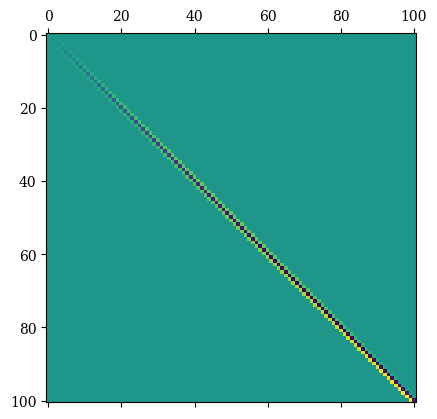

In [6]:
f, ax = plt.subplots()

ax.matshow(rMatrix(44, 100))

plt.show()

In [7]:
def simulate(N, A, stoptime, init):
    """return solution to kolmogorov equations given value for N, how long to simulate, and initial condition
    if init is "max", Ng(0) = A
    if init is "eq", Ng(0) is the equilibrium value from the deterministic model
    """
    #R matrix for give value of N
    r_matrix = rMatrix(N, A)

    #initial value
    p0 = np.zeros(A+1)
    if init == "max":
        p0[A]=1
    elif init == "eq":
        p0[int(A-N*R/K)]=1
    else:
        raise ValueError("init must be \"max\" or \"eq\"")

    #RHS of the system
    def sys(t, y):
        return np.matmul(y, r_matrix)
        
    st = time.time()
    
    s = sp.integrate.solve_ivp(sys, (0, stoptime), p0)
    
    print("finished solution N={0}, A={1}, Ng0 {2} in {3:.2f} seconds".format(N, A, init, time.time()-st))
    return s

finished solution N=25, A=50, Ng0 max in 1.47 seconds


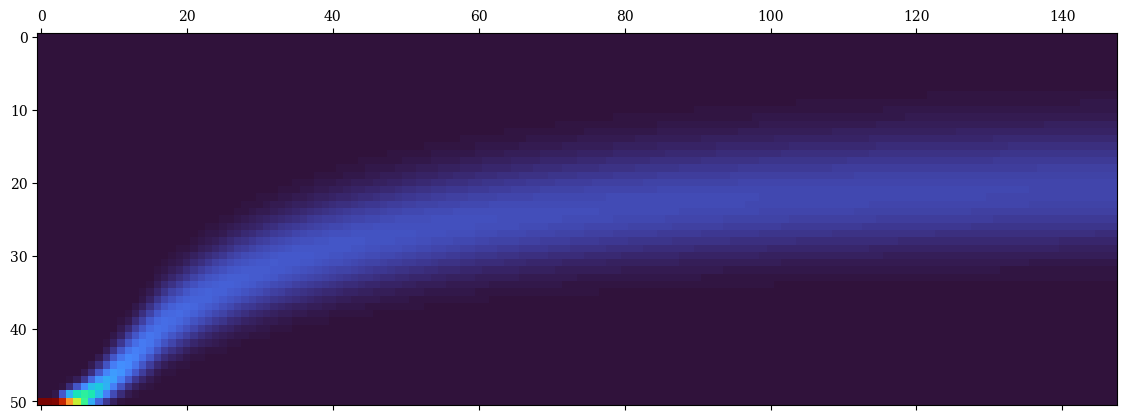

In [8]:
s = simulate(25, 50, 1000, "max")

plt.matshow(s["y"], cmap="turbo")

## Execute simulations

In [ ]:
sol_100 = {str(i): simulate(i, 100, 10000, "max") for i in range(5, 90, 5)}

sol_200 = {str(i): simulate(i, 200, 10000, "max") for i in range(10, 180, 10)}

sol_500 = {str(i): simulate(i, 500, 10000, "max") for i in range(25, 450, 25)}

## Save simulation results

In [ ]:
with open("kolmogorov_sol_100.dat", "wb") as f:
    pickle.dump(sol_100, f)

with open("kolmogorov_sol_200.dat", "wb") as f:
    pickle.dump(sol_200, f)

with open("kolmogorov_sol_500.dat", "wb") as f:
    pickle.dump(sol_500, f)